In [31]:
import numpy as np
import pandas as pd
import os
import time
from tqdm import tqdm, trange
import sys
import matplotlib.pyplot as plt

In [32]:
# variaveis
L = 100 # lado do lattice
n_lagartos = L**2 # lagartos que cabem no lattice
estrategias = ['O', 'Y', 'B'] # estratégias possíveis
a = 2 # ganho em fitness ao vencer
b = 1/a # ganho em fitness ao perder
matriz_payoff = np.array([[1, b, a],
                          [a, 1, b],
                          [b, a, 1]])
index_map = {'O': 0, 'Y': 1, 'B': 2}
n_geracoes = 100
n_pop = 100 # número de populações independentes
tipo = "homogenea" # tipo de vizinhança: "homogenea", "I", "II" ou "adaptativa"
prob_mutacao = None # probabilidade de mutação a cada geração
threshold_O = 0.9 # threshold para a proporção de O na vizinhança adaptativa
freq_inicial = [0.9, 0.05, 0.05] # frequências iniciais de O, Y e B
if tipo == "adaptativa":
    output_dir = "C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/" + tipo + "/" + f"_threshold_{threshold_O}/"
elif tipo == "homogenea":
    output_dir = "C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/" + tipo + "/" + f"freqO_{freq_inicial[0]}_freqY_{freq_inicial[1]}_freqB_{freq_inicial[2]}/"
else:
    output_dir = "C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/" + tipo + "/"

os.makedirs(output_dir, exist_ok=True)

Resumo

O código foi estruturado na forma de classes (programação orientada a objetos). Os indivíduos estão dentro da classe Lagarto e possuem os seguintes atributos:
- i e j: posição no espaço (lattice, i: linha, j: coluna)
- estrategia: estratégia do lagarto naquela posição (pode ser uma entre laranja (O), azul (B) e amarelo (Y)) no tempo t
- fitness: fitness do lagarto naquela posição no tempo t. É resultado da soma dos payoffs dos jogos com seus vizinhos
- coord_vizinhos: lista com as coordenadas dos vizinhos do lagarto. É dada no formato [[i1, j1], [i2, j2]...] (são duplex de coordenadas). É calculada a partir do tamanho da vizinhança do lagarto
- estrategia_vizinhos: lista com as estratégias dos vizinhos do lagarto. Serve para saber quais jogos o lagarto irá realizar
- coord_vizinhanca_estendida: lista com as coordenadas dos vizinhos da vizinhança estendida. É dada no formato [[i1, j1], [i2, j2]...]. A vizinhança estendida representa a adição de vizinhos que não estão na vizinhança inicial do lagarto focal, mas que o lagarto focal está na vizinhança inicial desses vizinhos. Esse atributo corrige o problema de interações recíprocas (se i joga com j, j tem que jogar com i)
- estrategia_vizinhanca_estendida: lista com as estrategias dos vizinhos da vizinhança estendida
- tipo_vizinhanca: determina o número de vizinhos que será usado para cada estratégia
    1. homogenea: todas as estratégas tem o mesmo número de vizinhos (vizinhança de Moore)
    2. I: Y possui maior vizinhança (Moore raio 3, 48), seguido de O (Moore raio 2, 24), seguido de B (Moore raio 1, 8). Tenta representar o padrão de movimento dos animais (maior movimento, maior número de vizinhos, pois maior o número de interações)
    3. II: O possui maior vizinhança (Moore raio 3), seguido de B e Y (Moore raio 2, 24). Tenta representar dados reais do tamanho do território retirados de literatura
    4. adaptativa: O possui maior vizinhança (Moore raio 3), seguido de B (Moore raio 2, 24). A estratégia amarela (Y) tem seu raio variável, de modo que, inicialmente, ela possui 24 vizinhos (igual B). Se a proporção de vizinhos laranjas for maior do que um valor de threshold, o lagarto mantém essa vizinhança. Se for menor, ele aumenta a sua vizinhança para a Moore raio 3 (igual O). A ideia é que o lagarto amarelo vai andar tanto quanto for necessário para adquirir recurso reprodutivo. 
- t: define o passo de tempo em que encontramos o lagarto
- n_vizinhos: define quantos vizinhos efetivamente o lagarto tem (somando normal + estendido)

Função lagarto.calcular_coord_vizinhos() TESTADO E FUNCIONANDO
- Objetivo: a partir do tipo de vizinhança pretendida, define quem são os vizinhos do lagarto
- Passo a passo: 
    1. Define o raio de Moore para cada estratégia (1, 2 ou 3) em um mapa
        - radius_map = {'B': x, 'O': y, 'Y': z}
    2. Verifica qual a estratégia do lagarto pra saber qual raio usar
    3. Pega as coordenadas nos vizinhos nas posições i+1, i-1, etc... com fronteíras periódicas de contorno (não existe fronteira)
        - ni = (self.i + x) % L # fronteiras periódicas (obtém a linha)
        - nj = (self.j + y) % L # obtém a coluna
        - não adiciona o próprio lagarto na lista de vizinhos
    4. Para vizinhança adaptativa:
        - calcula normalmanete para O e B
        - calcula normalmente para Y com raio 2
        - verifica quais as estratégias dos vizinhos de Y a partir da matriz de posições (!!! poderia ser feito por um mapa, sem precisar da matriz, posso ver depois de mudar!!!)
        - se a proporção de vizinhos laranjas for menor que o threshold dado, aumenta a vizinhança para raio 3
        - se não, mantém vizinhança de raio 2
- Adiciona uma lista no formato [[i1, j1], [i2, j2]...] no atributo coord_vizinhos do lagarto
    
Função lagarto.obter_estrategia_vizinhos() TESTADO E FUNCIONANDO
- Objetivo: a partir das coordenadas calculadas em lagarto.calcular_coord_vizinhos(), define qual a estratégia do lagarto nessa posição
- Utiliza a matriz de posição para pegar as estratégias (!!! poderia ser feito por um mapa, sem precisar da matriz, posso ver depois de mudar!!!)

Função lagarto.mutacao() TESTADO E FUNCIONANDO
- Objetivo: permite que o lagarto mude sua estratégia dada uma probabilidade de mutação

Função lagarto.calcular_n_vizinhos() TESTADO E FUNCIONANDO
- Objetivo: calcula o número efetivo de vizinhos que o lagarto tem, somando normal + estendido

Função calcular_media_vizinhos() TESTADO E FUNCIONANDO
- Objetivo: a partir do número de vizinhos calculado para cada lagarto, calcula a média do número de vizinhos para cada estratégia (ex: média 8 para azul)
- Passo a passo:
    1. Vai na ordem das estratégias dadas pela lista [O, Y, B]
    2. Calcula a média
    3. Se a média for 0 (ou seja, a estratégia foi extinta), fica 0

Função ajustar_vizinhos_reciprocos() TESTADO E FUNCIONANDO
- Objetivo: resolver o problema de reciprocidade nas interações. No nosso modelo, se i joga com j e soma um payoff ao fitness, j precisa jogar com i e somar o payoff recíproco ao seu próprio fitness. Biologicamente, é o que faz mais sentido
- Passo a passo:
    1. Define um mapa para acessar o lagarto que ocupa determinada posição
        - mapa = {(l.i, l.j): l for l in lagartos}
    2. Verifica todos os vizinhos do lagarto focal a partir de coord_vizinhos
    3. Se o vizinho não tiver o lagarto focal na sua lista coord_vizinhos, adiciona as coordenadas e a estratégia do lagarto focal nos atributos coord_vizinhanca_estendida e estrategia_vizinhanca_estendida do vizinho, respectivamente

In [33]:
class Lagarto:
  def __init__(self, i, j, estrategia, fitness, coord_vizinhos, estrategia_vizinhos, coord_vizinhanca_extendida, estrategia_vizinhanca_extendida, tipo_vizinhanca, t, n_vizinhos):
    self.i = i # linha
    self.j = j # coluna
    self.estrategia = estrategia
    self.fitness = 0 # inicia com 0 de fitness
    self.coord_vizinhos = [] # lista vazia para adicionar as coordenadas dos vizinhos
    self.estrategia_vizinhos = [] # lista vazia para adicionar as estratégias dos vizinhos
    self.coord_vizinhanca_extendida = []
    self.estrategia_vizinhanca_extendida = []
    self.tipo_vizinhanca = tipo # tipo de vizinhança "homogenea", "I" ou "II"
    self.t = 0 # determina a geracao do lagarto
    self.n_vizinhos = 0 # número de vizinhos

  def calcular_coord_vizinhos(self, L, matriz_posicao, threshold_O): # obtém as coordenadas dos vizinhos

      if self.tipo_vizinhanca == "homogenea":
        radius_map = {'B': 1, 'O': 1, 'Y': 1} # raio da vizinhança homogenea: todos com vizinhança de Moore (8 vizinhos)
        r = radius_map.get(self.estrategia, 1) # verifica qual a estrategia do lagarto pra saber qual vizinhança usar

        lista_vizinhos = []
        for x in range(-r, r + 1):
            for y in range(-r, r + 1):
                if x == 0 and y == 0: # não inclui o próprio lagarto na lista vizinhos
                    continue
                ni = (self.i + x) % L # fronteiras periódicas (obtém a linha)
                nj = (self.j + y) % L # obtém a coluna
                lista_vizinhos.append((ni, nj)) # retorna duplex (linha, coluna)
        self.coord_vizinhos = lista_vizinhos

      elif self.tipo_vizinhanca == "I":
        radius_map = {'B': 1, 'O': 2, 'Y': 3} # raio da vizinhança Y > O > B
        r = radius_map.get(self.estrategia, 1) # verifica qual a estrategia do lagarto pra saber qual vizinhança usar

        lista_vizinhos = []
        for x in range(-r, r + 1):
            for y in range(-r, r + 1):
                if x == 0 and y == 0: 
                    continue
                ni = (self.i + x) % L 
                nj = (self.j + y) % L 
                lista_vizinhos.append((ni, nj)) 
        self.coord_vizinhos = lista_vizinhos

      elif self.tipo_vizinhanca == "II":
        radius_map = {'B': 2, 'O': 3, 'Y': 2} # raio da vizinhança O > Y = B
        r = radius_map.get(self.estrategia, 1) # verifica qual a estrategia do lagarto pra saber qual vizinhança usar

        lista_vizinhos = []
        for x in range(-r, r + 1):
            for y in range(-r, r + 1):
                if x == 0 and y == 0: 
                    continue
                ni = (self.i + x) % L 
                nj = (self.j + y) % L
                lista_vizinhos.append((ni, nj)) 
        self.coord_vizinhos = lista_vizinhos
      
      elif self.tipo_vizinhanca == "adaptativa":
        radius_map = {'B': 2, 'O': 3, 'Y': 2} # raio da vizinhança adaptativa (Y pode ser igual a B ou O, dependendo do threshold)
        r = radius_map.get(self.estrategia, 1) # verifica qual a estrategia do lagarto pra saber qual vizinhança usar 

        lista_vizinhos = []
        if self.estrategia == 'O' or self.estrategia == "B" : # se for O ou B, usa vizinhança normal
          for x in range(-r, r + 1):
              for y in range(-r, r + 1):
                  if x == 0 and y == 0: 
                    continue 
                  ni = (self.i + x) % L 
                  nj = (self.j + y) % L 
                  lista_vizinhos.append((ni, nj)) 
        
        elif self.estrategia == 'Y': # se for Y, usa vizinhança adaptativa
            for x in range(-r, r + 1): # inicia com r = 2
              for y in range(-r, r + 1):
                  if x == 0 and y == 0: 
                    continue 
                  ni = (self.i + x) % L 
                  nj = (self.j + y) % L 
                  lista_vizinhos.append((ni, nj)) 
            estrategia_vizinhos = [matriz_posicao[ni, nj] for ni, nj in lista_vizinhos] # verifica quem são os vizinhos
            if sum(e == 'O' for e in estrategia_vizinhos) < threshold_O * len(estrategia_vizinhos): # se a proporção de O na vizinhança for menor que threshold, usa vizinhança maior
               r = 3 # vizinhança maior
               lista_vizinhos = []
               for x in range(-r, r + 1):
                 for y in range(-r, r + 1):
                   if x == 0 and y == 0: 
                    continue 
                   ni = (self.i + x) % L 
                   nj = (self.j + y) % L 
                   lista_vizinhos.append((ni, nj)) 

        self.coord_vizinhos = lista_vizinhos
    
  def obter_estrategia_vizinhos(self, matriz_posicao):
      self.estrategia_vizinhos = [matriz_posicao[ni, nj] for ni, nj in self.coord_vizinhos] # dadas as coordenadas, obtém a estratégia do lagarto que ocupa aquela posição

  def mutacao(self, prob_mutacao): # função de mutação
    if np.random.rand() < prob_mutacao: # sorteia um valor entre 0 e 1, se for menor que a probabilidade de mutação, o lagarto muda de estratégia
        estrategias_possiveis = [e for e in estrategias if e != self.estrategia] # obtém as estratégias possíveis, exceto a atual
        self.estrategia = np.random.choice(estrategias_possiveis) # escolhe uma nova estratégia aleatoriamente para mutar

  def calcular_n_vizinhos(self): # calcula o número de vizinhos
      self.n_vizinhos = len(self.estrategia_vizinhos) + len(self.estrategia_vizinhanca_extendida)

def calcular_media_vizinhos(lagartos, estrategias):
    medias = []
    for e in estrategias:
        viz = [lag.n_vizinhos for lag in lagartos if lag.estrategia == e]
        medias.append(np.mean(viz) if len(viz) > 0 else 0)
    return medias # retorna a média de vizinhos para cada estratégia

def ajustar_vizinhos_reciprocos(lagartos): # garante que se A é vizinho de B, B também é vizinho de A, pois as interações são recíprocas
    mapa = {(l.i, l.j): l for l in lagartos} # dicionário pra acessar lagartos pela posição

    for l in lagartos:
        for (ni, nj) in l.coord_vizinhos: # vai em todos os vizinhos do lagarto atual (l)
            vizinho = mapa[(ni, nj)]
            # se o lagarto atual (l) não estiver na lista de vizinhos do vizinho, adiciona em vizinhanca_extendida
            if (l.i, l.j) not in vizinho.coord_vizinhos:
                vizinho.estrategia_vizinhanca_extendida.append(str(l.estrategia))
                vizinho.coord_vizinhanca_extendida.append((l.i, l.j))

Função criar_lagartos()
- Objetivo: cria inicialmente os lagartos na classe
- Passo a passo:
    1. Define todas as posições posições possíveis no lattice (em duplex i,j)
    2. Embaralha essas posições (pois as posições iniciais são aleatórias)
    3. Sorteia qual a estratégia de cada lagarto em cada posição
        - a frequência inicial de cada estratégia pe definida por freq_inicial
            - np.random.choice(estrategias, p = freq_inicial)
    4. Cria os lagartos "crus": com a posição e estratégia sorteada, com fitness 0, sem vizinhos ainda e com o tipo de vizinhança determinada

Função calcular_fitness()
- Objetivo: calcular o fitness de cada lagarto sabendo as estratégias dos seus vizinhos (veio da função lagarto.obter_estrategia_vizinhos())
- Passo a passo:
    1. Pega todas as coordenadas dos vizinhos (normais e estentido), sem sobrepor
    2. Pega a estratégia dessas posições pela matriz de posição (!!! poderia ser feito por um mapa, sem precisar da matriz, posso ver depois de mudar!!!)
    3. Faz com que o lagarto focal jogue com todos os seus vizinhos e some seus payoffs dados pela matriz de payoff
    4. O payoff somado é o fitness

Função calcular freq
- Objetivo: calcular a frequência das estratégias em cada geração
- Devolve uma lista no formato [freqO, freqY, freqB], ex: [0.4, 0.6, 0.0]

In [34]:
def criar_lagartos(n_lagartos, L, estrategias, tipo, freq_inicial): # define as posições e estratégias dos lagartos no t = 0
  lista_lagartos = []

  # posições iniciais aleatórias
  all_positions = [(i, j) for i in range(L) for j in range(L)] # forma todas as posições possíveis em um lattice
  unique_positions_indices = np.random.choice(len(all_positions), n_lagartos, replace=False) # determina o índice de onde vai ficar cada posição
  unique_positions = [all_positions[i] for i in unique_positions_indices] # basicamente, ele embaralhou as posições

  for g in range(n_lagartos):
    i, j = unique_positions[g] # posição na matriz
    estrategia = np.random.choice(estrategias, p = freq_inicial) # sorteia a estrategia
    lista_lagartos.append(Lagarto(i, j, estrategia, 0, [], [], [], [], tipo, 0, 0)) # cria o lagarto
  return lista_lagartos

def calcular_fitness(lagarto, matriz_payoff, index_map, matriz_posicao): # função para calcular o fitness do lagarto
    fitness_total = 0 # inicia no 0
    
    todos_vizinhos = set(lagarto.coord_vizinhos + lagarto.coord_vizinhanca_extendida) # junta todos os vizinhos (normais e estendidos) em um set para evitar que um vizinho seja contado duas vezes
    for ni, nj in todos_vizinhos:
        vizinho_estrat = matriz_posicao[ni, nj] # pega a estratégia do vizinho dadas as suas coordenadas
        if vizinho_estrat is not None:
            fitness_total += matriz_payoff[index_map[lagarto.estrategia], index_map[vizinho_estrat]] # calcula o payoff do lagarto contra o vizinho de acordo com a matriz de payoff e soma ao fitness total
    lagarto.fitness = fitness_total
    return fitness_total

calcular_freq = lambda mat: np.array([np.sum(mat == s) / (L ** 2) for s in ['O', 'Y', 'B']]) # calcula a frequência de cada estratégia no lattice na ordem O, Y, B

Função atualizar_lagartos()
- Objetivo: atualiza a estratégia dos lagartos de acordo com a regra de que o lagarto, dentre ele próprio e seus vizinhos, que tiver o maior fitness, reproduz e ocupa a posição focal
- Passo a passo:
    1. Vai em cada lagarto 1 por 1
    2. Define a estrategia e o fitness do lagarto focal como o melhor
    3. Verifica o fitness dos vizinhos. Se for maior que o dele, o fitness do vizinho e a sua estratégia viram as novas melhores. Se houver empate, mantém a atual (!!!)
    4. Define a melhor estratégia no dicionário
        - novas_estrategias = {} 
        - novas_estrategias[(lagarto.i, lagarto.j)] = melhor_estrategia
    5. Depois de fazer isso para todos os lagartos, atualiza todos simultaneamente
        - lagarto.estrategia = novas_estrategias[(lagarto.i, lagarto.j)]
        - evita que a atualização de um lagarto influencie outro na mesma geração (sem sobreposição de geração)

In [35]:
def atualizar_lagartos(lagartos): # função que atualiza as estratégias dos lagartos com base no fitness dos vizinhos
    novas_estrategias = {} # Dicionário para armazenar as novas estratégias

    mapa = {(l.i, l.j): l for l in lagartos} # dicionário para acessar lagartos pela posição

    for lagarto in lagartos:
        melhor_estrategia = lagarto.estrategia # inicia com a própria estratégia
        maior_fitness = lagarto.fitness # verifica o fitness do próprio lagarto

        # verifica o fitness dos vizinhos normais
        for (ni, nj) in lagarto.coord_vizinhos:
            vizinho = mapa[(ni, nj)] # usa o dicionário para achar o vizinho
            if vizinho.fitness > maior_fitness: # se o fitness do vizinho for maior que o maior fitness atual
                maior_fitness = vizinho.fitness # atualiza o maior fitness
                melhor_estrategia = vizinho.estrategia # atualiza a melhor estratégia
                # se houver empate de fitness ou for menor, mantém a estratégia atual (não muda)

        # verifica o fitness dos vizinhos extendidos
        for (ni, nj) in lagarto.coord_vizinhanca_extendida:
            vizinho = mapa[(ni, nj)] 
            if vizinho.fitness > maior_fitness:
                maior_fitness = vizinho.fitness
                melhor_estrategia = vizinho.estrategia

        novas_estrategias[(lagarto.i, lagarto.j)] = melhor_estrategia # armazena a nova estratégia no dicionário

    # atualiza as estratégias de todos os lagartos simultaneamente
    for lagarto in lagartos:
        lagarto.estrategia = novas_estrategias[(lagarto.i, lagarto.j)] # evita que a atualização de um lagarto influencie outro na mesma geração (sem sobreposição de geração)

    
    return lagartos

Função simulacao()
- Objetivo: junta todas as funções anteriormente definidar e faz funcionar efetivamente
- Passo a passo da simulação: 
    1. Criar as matrizes principais onde os dados serão armazenados
        - as linhas são as gerações, e as colunas são as populações
        - as colunas são triplex com frequência e número médio de vizinhos em O, Y e B
    2. Inicia o loop das populações independentes 
    
        3. Utiliza as sementes de 1 a 100 para ser reproduzível
        4. Cria o vetor que armazena as frequências ao longo das gerações para cada população (é um vetor para cada pop)
        5. Cria os lagartos para a simulação
        6. Posiciona os lagartos numa matriz de posição
        7. Calcula a frequencia inicial das entratégias
        8. Inicia o loop das gerações

            9. Calcula os vizinhos dos lagartos
            10. Zera a lista de vizinhos estendidos pra não ter sobreposição de geração
            11. Ajusta as vizinhanças recíprocas
            12. Calcula o número de vizinhos
            13. Calcula a média do número de vizinhos por estratégia e adiciona na matriz principal
            14. Calcula o fitness de todos os lagartos
            15. Cria uma matriz de fitness (pra que?)
            16. Atualiza os lagartos
            17. Permite que eles mutem (caso queira)
            18. Cria uma nova matriz de posição com as novas estratégias atualizadas (atualiza o passo 6)
            19. Calcula as frequências de cada estratégia na matriz e adiciona no vetor frequencia (formato triplex)
            20. Aumenta o tempo em t+1 e vai pra próxima geração
            
        21. Ao final do loop das gerações, adiciona o vetor frequecia completo na matriz principal de frequência


In [36]:
from tqdm.notebook import tqdm

# iniciando a simulação
def simulacao(n_geracoes, L, n_lagartos, estrategias, matriz_payoff, index_map, n_pop, tipo, threshold_O, freq_inicial, prob_mutacao = None, seed = None):
    matriz_frequencias = np.full((n_geracoes + 1, n_pop, len(estrategias)), None) # cria uma matriz em que as linhas são as gerações, e as colunas são as populações
    # armazena as frequências das três estratégias
    matriz_n_vizinhos = np.full((n_geracoes + 1, n_pop, len(estrategias)), None)  # cria uma matriz para armazenar vizinhos


    for pop in tqdm(range(n_pop), desc = "Populações", position=0, leave = True): # loop para cada população independente
      if seed is not None:
          np.random.seed(seed + pop) # coloca uma semente diferente pra cada pop, garantindo independência

      frequencias = [] # vai armazenar as frequências ao longo das gerações para essa população
      lista_lagartos = criar_lagartos(n_lagartos, L, estrategias, tipo, freq_inicial) # cria os lagartos
      matriz_posicao = np.full((L, L), None) # cria uma matriz vazia com None
      for lagarto in lista_lagartos:
        matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia) # cria a matriz de posições de acordo com os lagartos

      frequencias.append(calcular_freq(matriz_posicao)) # calcula a frequência inicial

      for t in tqdm(range(1, n_geracoes + 1), desc="Gerações", position=1, leave=True): # loop para cada geração dentro da população
        # determinando os vizinhos
        for lagarto in lista_lagartos:
          lagarto.calcular_coord_vizinhos(L, matriz_posicao, threshold_O) # calcula as coordenadas dos vizinhos
          lagarto.obter_estrategia_vizinhos(matriz_posicao) # obtém as estratégias dos vizinhos

          lagarto.coord_vizinhanca_extendida = [] # zera a vizinhança estendida para recalcular
          lagarto.estrategia_vizinhanca_extendida = [] 

        ajustar_vizinhos_reciprocos(lista_lagartos) # ajusta as vizinhanças recíprocas

        for lagarto in lista_lagartos:
          lagarto.calcular_n_vizinhos() # calcula o número de vizinhos
        
        matriz_n_vizinhos[t, pop, :] = calcular_media_vizinhos(lista_lagartos, estrategias) # # calcula a média de vizinhos para cada estratégia e armazena na matriz de vizinhos

        # calculando o fitness
        for lagarto in lista_lagartos:
          calcular_fitness(lagarto, matriz_payoff, index_map, matriz_posicao) # calcula o fitness do lagarto de acordo com seus vizinhos e a matriz de fitness

        # criando a matriz de fitness
        matriz_fitness = np.full((L, L), None) # cria uma matriz vazia com None
        for lagarto in lista_lagartos:
          matriz_fitness[lagarto.i, lagarto.j] = float(lagarto.fitness) # coloca os fitness nas posições

        lista_lagartos = atualizar_lagartos(lista_lagartos) # atualiza as estratégias dos lagartos de acordo com o maior fitness dos vizinhos

        if prob_mutacao is not None:
          for lagarto in lista_lagartos:
            lagarto.mutacao(prob_mutacao) # aplica a mutação

        # atualiza a matriz de posição com as novas estratégias e com as mutações
        matriz_posicao = np.full((L, L), None)
        for lagarto in lista_lagartos:
          matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia)

        frequencias.append(calcular_freq(matriz_posicao)) # calcula a frequência dessa geração e armazena em frequencias

        for lagarto in lista_lagartos:
            lagarto.t += 1 # incrementa a geração do lagarto

      frequencias = np.array(frequencias)
      matriz_frequencias[:, pop, :] = frequencias

    return matriz_frequencias, matriz_n_vizinhos

freq, n_vizinhos = simulacao(n_geracoes, L, n_lagartos, estrategias, matriz_payoff, index_map, n_pop, tipo, threshold_O, freq_inicial, prob_mutacao, seed = 1)

Populações:   0%|          | 0/100 [00:00<?, ?it/s]

Gerações:   0%|          | 0/100 [00:00<?, ?it/s]

Gerações:   0%|          | 0/100 [00:00<?, ?it/s]

Gerações:   0%|          | 0/100 [00:00<?, ?it/s]

Gerações:   0%|          | 0/100 [00:00<?, ?it/s]

...

Gerações:   0%|          | 0/100 [00:00<?, ?it/s]

Gerações:   0%|          | 0/100 [00:00<?, ?it/s]

Gerações:   0%|          | 0/100 [00:00<?, ?it/s]

Gerações:   0%|          | 0/100 [00:00<?, ?it/s]

Gerações:   0%|          | 0/100 [00:00<?, ?it/s]

Salva a matriz de frequências em um csv em formato tidy onde:

    - Coluna 1: geração
    - Coluna 2: população
    - Coluna 3: estratégia
    - Coluna 4: frequência média

In [37]:
# transforma freq em DataFrame formato tidy
linhas = []
for t in range(freq.shape[0]):             # gerações
    for pop in range(freq.shape[1]):       # populações
        for idx, strategy in enumerate(estrategias):  # estratégias
            linhas.append({
                "t": t, # coluna 1: geração
                "pop": pop, # coluna 2: população
                "estrategia": strategy, # coluna 3: estrategia
                "frequencia": freq[t, pop, idx] # coluna 4: frequência da estratégia naquela geração, naquela população
            })

df_long = pd.DataFrame(linhas)

# salvar como CSV
df_long.to_csv(os.path.join(output_dir, "frequencias_tipo" + tipo + ".csv"), index=False)

Salva a matriz de número de vizinhos em um csv em formato tidy onde:

    - Coluna 1: geração
    - Coluna 2: população
    - Coluna 3: estratégia
    - Coluna 4: número de vizinhos médio

In [38]:
# salva a matriz de vizinhos como DataFrame formato tidy
linhas = []
n_vizinhos = np.array(n_vizinhos, dtype=float)  # converte para float para evitar problemas com None

for t in range(n_vizinhos.shape[0]):          # gerações
    for pop in range(n_vizinhos.shape[1]):    # populações
        for idx, strategy in enumerate(estrategias):  # estratégias
            linhas.append({
                "t": t,                        # geração
                "pop": pop,                    # população
                "estrategia": strategy,        # estratégia
                "n_vizinhos": n_vizinhos[t, pop, idx]  # média de vizinhos
            })

df_n_vizinhos = pd.DataFrame(linhas)

# salvar como CSV
df_n_vizinhos.to_csv(os.path.join(output_dir, f"n_vizinhos.csv"), index=False)

#print(df_n_vizinhos.head(10))


Plota as frequências de todas as populações independentes 

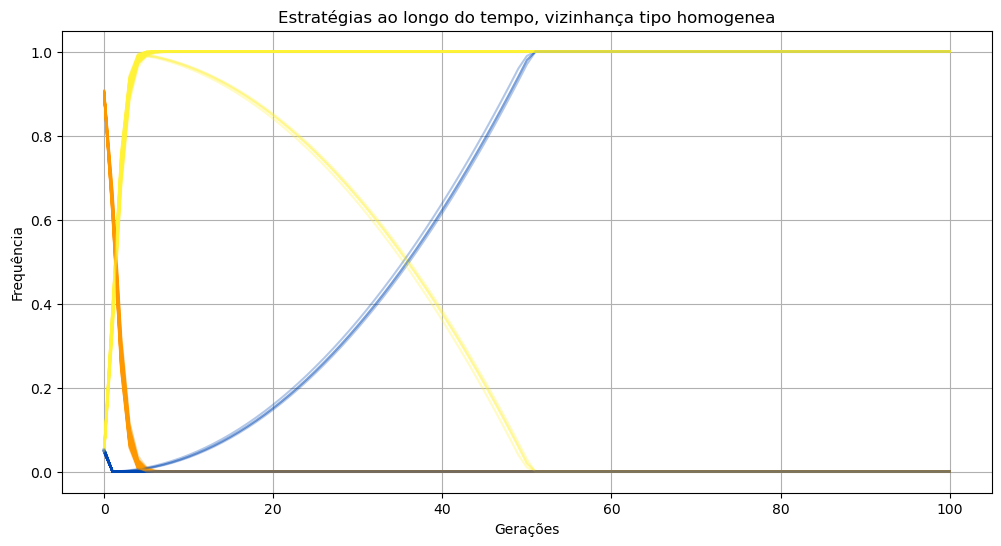

In [39]:
cores = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

plt.figure(figsize=(12, 6))

for pop in range(freq.shape[1]):  # para cada simulação
    for idx, strategy in enumerate(estrategias):
        plt.plot(
            range(freq.shape[0]),
            freq[:, pop, idx],
            label=f"{strategy} (sim {pop+1})",
            color=cores[strategy],
            alpha = 0.3
        )

plt.title("Estratégias ao longo do tempo, vizinhança tipo " + tipo)
plt.xlabel("Gerações")
plt.ylabel("Frequência")
plt.grid(True)
plt.savefig(os.path.join(output_dir, "plot_freq_todos_tipo_" + tipo + ".png"), dpi = 300, bbox_inches='tight')
plt.show()

Plota a média com o desvio de todas as 100 populações

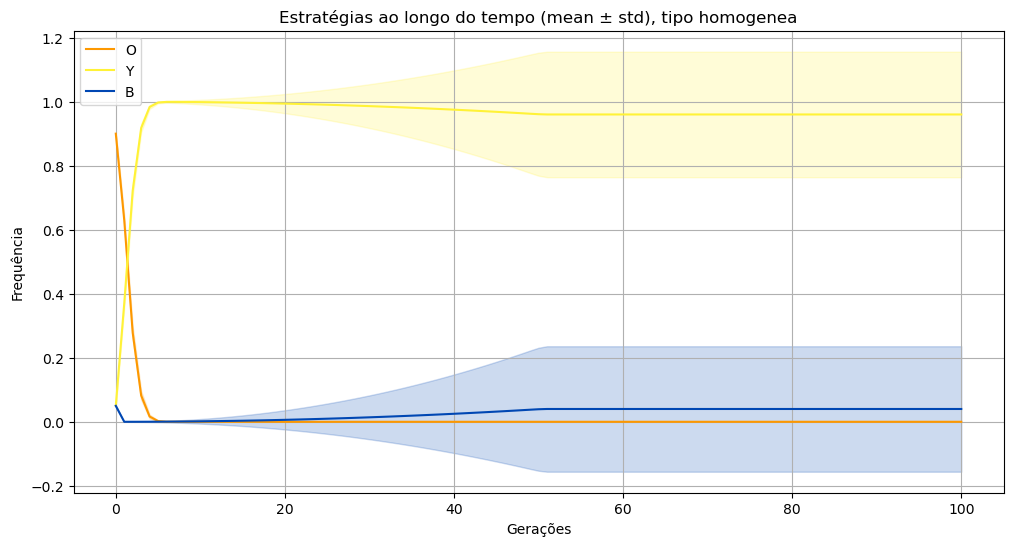

In [40]:
cores = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

plt.figure(figsize=(12, 6))

for idx, strategy in enumerate(estrategias):
    media = np.array(freq[:, :, idx], dtype=float).mean(axis=1)
    desvio = np.array(freq[:, :, idx], dtype=float).std(axis=1)


    plt.plot(range(freq.shape[0]), media, label=strategy, color=cores[strategy])
    plt.fill_between(range(freq.shape[0]), media-desvio, media+desvio,
                     color=cores[strategy], alpha=0.2)

plt.title("Estratégias ao longo do tempo (mean ± std), tipo " + tipo)
plt.xlabel("Gerações")
plt.ylabel("Frequência")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, "plot_freq_media_tipo_" + tipo + ".png"), dpi = 300, bbox_inches='tight')
plt.show()

Função simulacao_gif()
- Objetivo: armazenar a estratégia dos lagartos em todas as gerações para montar um gif com as posições
- Tem formato parecido com o da função simulacao(), mas não tem o loop das gerações

In [41]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt

def simulacao_gif(n_geracoes, L, n_lagartos, estrategias, matriz_payoff, index_map, tipo, threshold_O, freq_inicial, prob_mutacao, seed = None):

    matrizes_posicao_hist = [] # lista para armazenar as matrizes de posição de cada geração
    matrizes_fitness_hist = []

    if seed is not None:
        np.random.seed(seed) # coloca uma semente diferente pra cada pop

    # criando a matriz inicial
    lista_lagartos = criar_lagartos(n_lagartos, L, estrategias, tipo, freq_inicial)
    matriz_posicao = np.full((L, L), None) # cria uma matriz vazia com None
    matriz_fitness = np.full((L, L), 0.0) # cria uma matriz vazia com 0

    for lagarto in lista_lagartos:
      matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia) # coloca os lagartos nas posições
    matrizes_posicao_hist.append(matriz_posicao.copy()) # junta as matrizes em uma lista
    matrizes_fitness_hist.append(matriz_fitness.copy())

    for t in trange(1, n_geracoes + 1, desc="Gerações", leave=False):
    # criando os vizinhos
      for lagarto in lista_lagartos:
        lagarto.calcular_coord_vizinhos(L, matriz_posicao, threshold_O)
        lagarto.obter_estrategia_vizinhos(matriz_posicao)

        lagarto.coord_vizinhanca_extendida = []
        lagarto.estrategia_vizinhanca_extendida = []

      ajustar_vizinhos_reciprocos(lista_lagartos)

      # calculando o fitness
      for lagarto in lista_lagartos:
        calcular_fitness(lagarto, matriz_payoff, index_map, matriz_posicao)

      # criando a matriz de fitness
      matriz_fitness = np.full((L, L), 0.0)
      for lagarto in lista_lagartos:
        matriz_fitness[lagarto.i, lagarto.j] = float(lagarto.fitness) # coloca os fitness nas posições
      #print(matriz_fitness)

      lista_lagartos = atualizar_lagartos(lista_lagartos)

      # atualiza a matriz de posição com as novas estratégias e com as mutações
      matriz_posicao = np.full((L, L), None)
      for lagarto in lista_lagartos:
        matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia)

      for lagarto in lista_lagartos:
            lagarto.t += 1

      matrizes_posicao_hist.append(matriz_posicao.copy()) # Append updated matrix position
      matrizes_fitness_hist.append(matriz_fitness.copy())

    return matrizes_posicao_hist, matrizes_fitness_hist # Return both frequencies and matrix history

matrizes_posicao_hist, matrizes_fitness_hist = simulacao_gif(n_geracoes, L, n_lagartos, estrategias, matriz_payoff, index_map, tipo, threshold_O, freq_inicial, prob_mutacao, seed=1)

In [42]:
# gerando o GIF das posições

import matplotlib.colors as mcolors

cores_grid = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

def matriz_para_rgb(matriz):
    # Converte hex para RGB normalizado (0-1)
    return np.array([[mcolors.to_rgb(cores_grid.get(cell, "#FFFFFF")) for cell in row] for row in matriz])

# Crie a figura
fig, ax = plt.subplots(figsize=(6, 6))

def update(frame):
    ax.clear()
    ax.imshow(matriz_para_rgb(matrizes_posicao_hist[frame]))
    ax.set_title(f"Geração {frame}")
    ax.axis('off')

ani = animation.FuncAnimation(
    fig, update, frames=len(matrizes_posicao_hist), interval=100, repeat=False
)


# Salvar como GIF
ani.save(os.path.join(output_dir, f"simulacao_grid_tipo_{tipo}.gif"), writer='pillow', fps=10)
ani.save(os.path.join(output_dir, f"simulacao_grid_tipo_{tipo}.mp4"), writer='ffmpeg', fps=5)
plt.close()

In [43]:
# gerando o GIF dos fitness

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(matrizes_fitness_hist[0], cmap='viridis', vmin=0, vmax=np.max(matrizes_fitness_hist))
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Fitness')

def update_fitness(frame):
    im.set_data(matrizes_fitness_hist[frame])
    ax.set_title(f"Fitness - Geração {frame}")
    ax.axis('off')
    return [im]

ani = animation.FuncAnimation(
    fig, update_fitness, frames=len(matrizes_fitness_hist), interval=100, blit=False, repeat=False
)

ani.save(os.path.join(output_dir, f"simulacao_fitness_tipo_{tipo}.gif"), writer='pillow', fps=10)
ani.save(os.path.join(output_dir, f"simulacao_fitness_tipo_{tipo}.mp4"), writer='ffmpeg', fps=5)
plt.close()

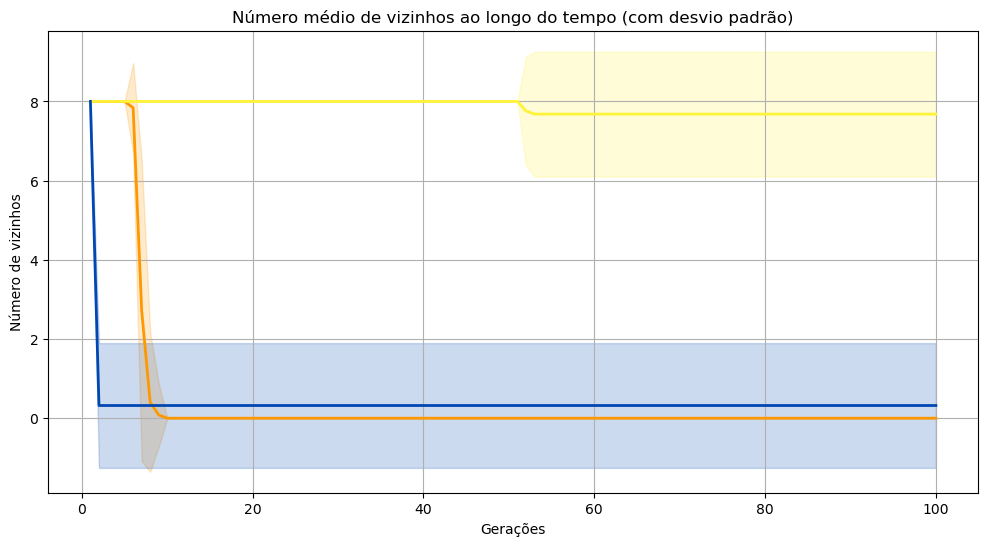

In [44]:
# agrupa por geração e estratégia -> calcula média e desvio entre populações
grouped = df_n_vizinhos.groupby(["t", "estrategia"])["n_vizinhos"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(12, 6))

for strategy in estrategias:
    dados = grouped[grouped["estrategia"] == strategy]
    
    # curva da média
    plt.plot(
        dados["t"], 
        dados["mean"], 
        label=strategy, 
        color=cores[strategy], 
        linewidth=2
    )
    
    # faixa do desvio padrão
    plt.fill_between(
        dados["t"], 
        dados["mean"] - dados["std"], 
        dados["mean"] + dados["std"], 
        color=cores[strategy], 
        alpha=0.2
    )

plt.title("Número médio de vizinhos ao longo do tempo (com desvio padrão)")
plt.xlabel("Gerações")
plt.ylabel("Número de vizinhos")
plt.grid(True)
#plt.legend()
plt.savefig(os.path.join(output_dir, "plot_n_vizinhos_media_std.png"), dpi=300, bbox_inches='tight')
plt.show()